In [1]:
print("Hello")

Hello


In [2]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode
import requests
from dotenv import load_dotenv

load_dotenv()

/home/yash/Desktop/Code/3. LangGraph and Ollama/langgraph_venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [ ]:
TOGETHER_BASE_URL="https://api.together.ai/v1"
TOGETHER_API_KEY=""
OPENAI_OSS_MODEL="OpenAI/gpt-oss-20B"
LIQUID_AI="LiquidAI/LFM2-24B-A2B"
QWEN="Qwen/Qwen3.5-9B"

llm = ChatOpenAI(
  model=QWEN,
  api_key=TOGETHER_API_KEY,
  base_url=TOGETHER_BASE_URL
)

class AgentState(TypedDict):
  messages: Annotated[list, operator.add]

## Tools

In [5]:
@tool
def get_weather(location:str) -> str:
    """Get current weather for a location.
    
    Use for queries about weather, temperature, or conditions in any city.
    Examples: "weather in Paris", "temperature in Tokyo", "is it raining in London"
    
    Args:
        location: City name (e.g., "New York", "London", "Tokyo")
        
    Returns:
        Current weather information including temperature and conditions.
    """

    url = f"https://wttr.in/{location}?format=j1"
    response = requests.get(url, timeout=10)

    response.raise_for_status()
    data = response.json()

    return data

@tool
def calculate(expression: str) -> str:
    """Calculate a mathematical expression.
    
    USE THIS TOOL FOR:
    - Any mathematical calculations or arithmetic operations
    - Queries involving numbers and operators (+, -, *, /, **, %)
    - Questions asking to compute, calculate, or solve math problems
    - Evaluating mathematical expressions
    
    EXAMPLE QUERIES:
    - "What is 2 + 2?"
    - "Calculate 15 times 7"
    - "Solve 100 / 4"
    - "What's 5 to the power of 3?"
    - "Compute 45 * 12 + 30"
    
    DO NOT USE FOR:
    - Word problems without explicit expressions (extract the math first)
    - Questions about mathematical concepts or theory

    Args:
        expression: Math expression like "2 + 2" or "15 * 7" (use standard Python operators)
    """

    try:
        result = eval(expression)
        print(f"[TOOL] calculate ('{expression}') -> '{result}'")
    except Exception as e:
        print(f"Exception has occured with error: {e}")
        return f"Exception has occured with error: {e}"

    return result

In [6]:
# get_weather.invoke({'location':"Hyderabad"})
# calculate.invoke({"expression": "2-2"})

In [7]:
all_tools = [get_weather, calculate]

def agent_node(state:AgentState):
  llm_with_tools = llm.bind_tools(all_tools)

  messages = state['messages']
  response = llm_with_tools.invoke(messages)
  if hasattr(response, 'tool_calls') and response.tool_calls:
      for tc in response.tool_calls:
        print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
  else:
      print("[AGENT] Responding...")

  return {'messages': [response]}


In [8]:
from langchain_core.messages import HumanMessage

query_1="Hi"
query_2="WHat is the Weather of Hyderabad?"
query_3="WHat is 2+2?"
query_4 = "What is the current weather in Mumbai? and What is 4*56 and 3-90"


In [9]:
state = {"messages": [HumanMessage(query_2)]}
response = agent_node(state)

[AGENT] called Tool get_weather with args {'location': 'Hyderabad'}


## Routing

In [11]:
def should_continue(state: AgentState):
    last = state['messages'][-1]
    
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    else:
        return END

In [12]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_weather (call_1201792de3ca453e95768577)
 Call ID: call_1201792de3ca453e95768577
  Args:
    location: Hyderabad


In [ ]:
def create_agent():

    builder = StateGraph(AgentState)

    builder.add_node("agent", agent_node)
    builder.add_node("tools", ToolNode(all_tools))

    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", should_continue, ["tools", END])
    builder.add_edge("tools", "agent")

    graph = builder.compile()

    return graph
  


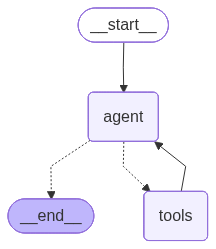

In [27]:
create_agent()

In [37]:
resp = create_agent().invoke({"messages": [HumanMessage(query_4)]})

[AGENT] called Tool get_weather with args {'location': 'Mumbai'}
[AGENT] called Tool calculate with args {'expression': '4*56'}
[AGENT] called Tool calculate with args {'expression': '3-90'}
[TOOL] calculate ('4*56') -> '224'
[TOOL] calculate ('3-90') -> '-87'
[AGENT] Responding...


In [38]:
resp['messages'][-1].pretty_print()

================================== Ai Message ==================================

The current weather in Mumbai:
- **Temperature**: 33°C (92°F)
- **Feels like**: 44°C (111°F)
- **Conditions**: Haze
- **Humidity**: 67%
- **Wind**: 21 km/h from the West

Also, for your calculations:
- **4 × 56 = 224**
- **3 - 90 = -87**
